In [ ]:
# Daily Challenge: Image Classification with Data Augmentation (Cats vs Dogs) - Vendredi 11 JUILLET 2025
    # 🛠️ What you will create
          # A binary image classification model to distinguish between images of cats and dogs.
          # A visualization of training and validation metrics to analyze model performance.

  # Objectif du Daily Challenge : créer un modèle de classification binaire pour distinguer les images de chats et de chiens, en utilisant la data augmentation pour améliorer la généralisation.

In [ ]:
# What You Need to Do
  # 1. Preprocess the Data:
      # Download and extract the Cats vs Dogs dataset here.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [1]:
# Importation des librairies nécessaires
from google.colab import drive
import os, zipfile, shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# 1.1  Accès à Google Drive et chargement des données

## 🔗 Connexion à Google Drive et accès au dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 1.2. Définir les chemins d'accès sous GOOGLE COLAB - Réorganisation des images en sous-dossiers
train_dir = "/content/drive/MyDrive/Colab_Notebooks/DAILY_CHALLENGE/train"
validation_dir = "/content/drive/MyDrive/Colab_Notebooks/DAILY_CHALLENGE/test"

In [ ]:
# 1.3. Paramètres d’image
IMG_HEIGHT = 150
IMG_WIDTH = 150
batch_size = 32

# 1.4. Importer les outils de traitement d'image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# 1.5. Générateur pour les images d'entraînement avec augmentation
train_image_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.5
)

In [ ]:
# 1.6. Générateur pour les images de validation sans augmentation
validation_image_generator = ImageDataGenerator(rescale=1./255)

In [ ]:
!ls /content/drive/MyDrive/Colab_Notebooks/DAILY_CHALLENGE

In [ ]:
# Création de dossiers 'cats' et 'dogs'
!mkdir -p "/content/drive/MyDrive/Colab_Notebooks/DAILY_CHALLENGE/train/cats"
!mkdir -p "/content/drive/MyDrive/Colab_Notebooks/DAILY_CHALLENGE/train/dogs"

# déplaceR les images
!mv /content/drive/MyDrive/Colab_Notebooks/DAILY_CHALLENGE/train/cat* \
    /content/drive/MyDrive/Colab_Notebooks/DAILY_CHALLENGE/train/cats/

!mv /content/drive/MyDrive/Colab_Notebooks/DAILY_CHALLENGE/train/dog* \
    /content/drive/MyDrive/Colab_Notebooks/DAILY_CHALLENGE/train/dogs/

In [ ]:
import os

train_dir = "/content/drive/MyDrive/Colab_Notebooks/DAILY_CHALLENGE/train"

# Vérifie si le dossier existe
if os.path.exists(train_dir):
    contenu = os.listdir(train_dir)
    print("Contenu de train_dir :")
    for item in contenu:
        chemin = os.path.join(train_dir, item)
        if os.path.isdir(chemin):
            print(f"📁 Dossier : {item}")
        elif os.path.isfile(chemin):
            print(f"🖼️ Fichier (image probablement) : {item}")
else:
    print("❌ train_dir n'existe pas")

In [ ]:
import shutil

# Crée les sous-dossiers s’ils n’existent pas
os.makedirs(os.path.join(train_dir, "cats"), exist_ok=True)
os.makedirs(os.path.join(train_dir, "dogs"), exist_ok=True)

# Déplace les images en fonction de leur nom
for filename in os.listdir(train_dir):
    filepath = os.path.join(train_dir, filename)

    if os.path.isfile(filepath):
        if filename.lower().startswith("cat"):
            shutil.move(filepath, os.path.join(train_dir, "cats", filename))
        elif filename.lower().startswith("dog"):
            shutil.move(filepath, os.path.join(train_dir, "dogs", filename))

In [ ]:
import os

test_dir = "/content/drive/MyDrive/Colab_Notebooks/DAILY_CHALLENGE/test"

if os.path.exists(test_dir):
    contenu = os.listdir(test_dir)
    print("Contenu de test_dir :")
    for item in contenu:
        chemin = os.path.join(test_dir, item)
        if os.path.isdir(chemin):
            print(f"📁 Dossier : {item}")
        elif os.path.isfile(chemin):
            print(f"🖼️ Fichier : {item}")
else:
    print("❌ test_dir n'existe pas")

In [15]:
# Réorganisation des images en sous-dossiers

import shutil
import os

# Chemin vers le dossier test dans Google Drive
test_dir = "/content/drive/MyDrive/Colab Notebooks/DAILY CHALLENGE/test"

# Crée les sous-dossiers si besoin
os.makedirs(os.path.join(test_dir, "cats"), exist_ok=True)
os.makedirs(os.path.join(test_dir, "dogs"), exist_ok=True)

# Déplace les fichiers selon leur nom
for filename in os.listdir(test_dir):
    filepath = os.path.join(test_dir, filename)

    if os.path.isfile(filepath):
        if filename.lower().startswith("cat"):
            shutil.move(filepath, os.path.join(test_dir, "cats", filename))
        elif filename.lower().startswith("dog"):
            shutil.move(filepath, os.path.join(test_dir, "dogs", filename))

In [7]:
# 1.7. Prétraitement des données avec augmentation - Créer les générateurs

train_image_generator = ImageDataGenerator(rescale=1./255)
validation_image_generator = ImageDataGenerator(rescale=1./255)

train_data_gen = train_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=train_dir,
    shuffle=True,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary'
)
val_data_gen = validation_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary'
)

Found 300 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [16]:
# What You Need to Do
  # 2. Create a CNN with:
      # Three convolutional layers with ReLU activation and max-pooling.
      # Dropout layers to reduce overfitting.
      # A fully connected layer with 512 units and ReLU activation.
      # An output layer with a single unit and sigmoid activation for binary classification.
      # Compile the model using the Adam optimizer and binary cross-entropy loss.

#  Construction du modèle CNN avec 3 couches convolutives
# Étape 1 : Importer les bibliothèques nécessaires
import tensorflow as tf
from tensorflow.keras import layers, models

# Étape 2 : Créer le modèle séquentiel
model = models.Sequential()

# 1ère couche convolutionnelle
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D(2, 2))

# 2e couche convolutionnelle
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))

# 3e couche convolutionnelle
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))

# Étape 3 : Flatten et Dropout
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))

# Étape 4 : Couche dense fully connected
model.add(layers.Dense(512, activation='relu'))

# Étape 5 : Couche de sortie binaire
model.add(layers.Dense(1, activation='sigmoid'))

# Étape 6 : Compilation du modèle
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Afficher le résumé du modèle
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Monter Google Drive dans l’environnement Colab
from google.colab import drive
drive.mount('/content/drive')
drive.mount("/content/drive", force_remount=True)

In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks/DAILY CHALLENGE/train" -l

In [ ]:
# 3. Train the Model:
    # Train the model on the augmented training data for 15 epochs.
    # Use the validation data to monitor performance during training.

    # Script de restructuration automatique des images

import os
import shutil

      # pour le dossier "train" :

train_path = "/content/drive/MyDrive/Colab Notebooks/DAILY CHALLENGE/train"

cats_dir = os.path.join(train_path, "cats")
dogs_dir = os.path.join(train_path, "dogs")

      # Créer les sous-dossiers si besoin
os.makedirs(cats_dir, exist_ok=True)
os.makedirs(dogs_dir, exist_ok=True)

      # Déplacer les images dans les bons dossiers
for fname in os.listdir(train_path):
    fpath = os.path.join(train_path, fname)
    if os.path.isfile(fpath):
        if fname.lower().startswith("cat"):
            shutil.move(fpath, os.path.join(cats_dir, fname))
        elif fname.lower().startswith("dog"):
            shutil.move(fpath, os.path.join(dogs_dir, fname))

In [143]:
      # ... idem pour le dossier "test" :

import os
import shutil

# Définir le chemin vers le dossier test
test_path = "/content/drive/MyDrive/Colab Notebooks/DAILY CHALLENGE/test"

# Définir les sous-dossiers pour les classes
cats_dir = os.path.join(test_path, "cats")
dogs_dir = os.path.join(test_path, "dogs")

# Créer les sous-dossiers s'ils n'existent pas
os.makedirs(cats_dir, exist_ok=True)
os.makedirs(dogs_dir, exist_ok=True)

In [ ]:
# Transfert des images vers les bons sous-dossiers
for fname in os.listdir(test_path):
    fpath = os.path.join(test_path, fname)
    if os.path.isfile(fpath):  # Ne traite que les fichiers
        if fname.lower().startswith("cat"):
            shutil.move(fpath, os.path.join(cats_dir, fname))
        elif fname.lower().startswith("dog"):
            shutil.move(fpath, os.path.join(dogs_dir, fname))

In [21]:
# 4. Chargement des images pour l'entraînement avec `ImageDataGenerator`
    # Préparation des images avec rescaling (mise à l’échelle des pixels)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 32
IMG_HEIGHT = 150
IMG_WIDTH = 150

train_dir = "/content/drive/MyDrive/Colab Notebooks/DAILY CHALLENGE/train"

# Générateur de données avec normalisation des pixels (entre 0 et 1)
train_image_generator = ImageDataGenerator(rescale=1./255)

# Chargement des images depuis le dossier train
train_data_gen = train_image_generator.flow_from_directory(
    directory=train_dir,
    batch_size=batch_size,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    shuffle=True,
    class_mode='binary'
)

# Vérification du contenu du dossier
!ls "/content/drive/MyDrive/Colab_Notebooks/DAILY_CHALLENGE"

Found 200 images belonging to 2 classes.
test  train


In [18]:
# Comptage du nombre d'images par classe dans le dossier d'entraînement

import os

for label in ['cats', 'dogs']:
    chemin = os.path.join(train_dir, label)
    print(f"{label} → {len(os.listdir(chemin))} fichiers")

cats → 101 fichiers
dogs → 99 fichiers


In [19]:
# Comptage du nombre d'images par classe dans le dossier test

import os

for label in ['cats', 'dogs']:
    chemin = os.path.join(test_dir, label)
    print(f"{label} → {len(os.listdir(chemin))} fichiers")

cats → 50 fichiers
dogs → 50 fichiers


In [17]:
import shutil
import os

# Crée les sous-dossiers si nécessaire
os.makedirs(os.path.join(test_dir, "cats"), exist_ok=True)
os.makedirs(os.path.join(test_dir, "dogs"), exist_ok=True)

# Chemins des fichiers sources
train_cats_dir = os.path.join(train_dir, "cats")
train_dogs_dir = os.path.join(train_dir, "dogs")

# Déplacer 50 chats et 50 chiens vers test_dir
for filename in os.listdir(train_cats_dir)[:50]:
    shutil.move(os.path.join(train_cats_dir, filename), os.path.join(test_dir, "cats", filename))

for filename in os.listdir(train_dogs_dir)[:50]:
    shutil.move(os.path.join(train_dogs_dir, filename), os.path.join(test_dir, "dogs", filename))

    val_data_gen = validation_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=test_dir,  #
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary'
)

Found 51 images belonging to 2 classes.
Found 52 images belonging to 2 classes.
Found 53 images belonging to 2 classes.
Found 54 images belonging to 2 classes.
Found 55 images belonging to 2 classes.
Found 56 images belonging to 2 classes.
Found 57 images belonging to 2 classes.
Found 58 images belonging to 2 classes.
Found 59 images belonging to 2 classes.
Found 60 images belonging to 2 classes.
Found 61 images belonging to 2 classes.
Found 62 images belonging to 2 classes.
Found 63 images belonging to 2 classes.
Found 64 images belonging to 2 classes.
Found 65 images belonging to 2 classes.
Found 66 images belonging to 2 classes.
Found 67 images belonging to 2 classes.
Found 68 images belonging to 2 classes.
Found 69 images belonging to 2 classes.
Found 70 images belonging to 2 classes.
Found 71 images belonging to 2 classes.
Found 72 images belonging to 2 classes.
Found 73 images belonging to 2 classes.
Found 74 images belonging to 2 classes.
Found 75 images belonging to 2 classes.


Found 200 images belonging to 2 classes.


In [150]:
print(validation_dir)

/content/drive/MyDrive/Colab_Notebooks/DAILY_CHALLENGE/test


In [151]:
validation_dir = "/content/drive/MyDrive/Colab_Notebooks/DAILY_CHALLENGE/test"

In [153]:
#. Regénèrer le générateur d'entraînement juste avant l’entraînement :

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_image_generator = ImageDataGenerator(rescale=1./255)
train_data_gen = train_image_generator.flow_from_directory(
    batch_size=batch_size,
    directory=train_dir,
    shuffle=True,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary'
)
# Entraîner à nouveau :

history = model.fit(
    train_data_gen,
    steps_per_epoch=train_data_gen.samples // batch_size,
    epochs=epochs,
    validation_data=val_data_gen,
    validation_steps=val_data_gen.samples // batch_size
)

Found 300 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5020 - loss: 0.6918

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5070 - loss: 0.6915 - val_accuracy: 0.5885 - val_loss: 0.6810
Epoch 2/15
1/9 ━━━━━━━━━━━━━━━━━━━━ 5s 672ms/step - accuracy: 0.5833 - loss: 0.6816

...

9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 640ms/step - accuracy: 0.8438 - loss: 0.3899 - val_accuracy: 0.5521 - val_loss: 0.9114
Epoch 11/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.7810 - loss: 0.5165 - val_accuracy: 0.6458 - val_loss: 0.6474
Epoch 12/15
1/9 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9375 - loss: 0.4586

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 344ms/step - accuracy: 0.9375 - loss: 0.4586 - val_accuracy: 0.6146 - val_loss: 0.6522
Epoch 13/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8201 - loss: 0.4741 - val_accuracy: 0.5677 - val_loss: 0.8080
Epoch 14/15
1/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7500 - loss: 0.4717

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 616ms/step - accuracy: 0.7500 - loss: 0.4717 - val_accuracy: 0.5469 - val_loss: 0.7819
Epoch 15/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8688 - loss: 0.3086 - val_accuracy: 0.5833 - val_loss: 0.8049


In [ ]:
assert os.path.exists(validation_dir), "⚠️ Dossier de validation non trouvé !"

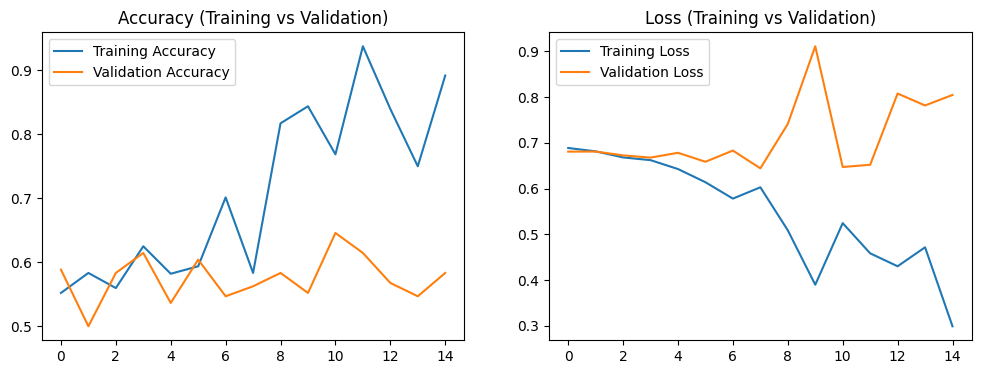

In [154]:
# Visualisation des courbes et évaluation du modèle : tracer les courbes

import matplotlib.pyplot as plt

# Récupérer l'historique d'entraînement
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Afficher les courbes
plt.figure(figsize=(12, 4))

# Courbe de précision
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title("Accuracy (Training vs Validation)")
plt.legend()

# Courbe de perte
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title("Loss (Training vs Validation)")
plt.legend()

plt.show()

In [ ]:
# Commentaires :
    # Courbe Accuracy (Précision) - Training curb (bleu) augmente fortement jusqu’à ~0.95, ce qui montre que le modèle s’ajuste très bien aux données d’entraînement.
    # Validation Accuracy (orange) reste bloquée entre 0.5 et 0.65, sans progression significative, et même en légère dégringolade après l'époque 10.

    # Courbe Loss (Perte) - Training Loss diminue régulièrement : le modèle s’améliore bien sur les données d’entraînement.
    # Validation Loss augmente après l’époque 6–7, avec des pics marqués

    Pour les 2 courbes, cela met en évidence un surapprentissage (overfitting).

In [159]:
# Actions pour tenter de réduire ces phénomènes de surapprentissage (overfitting) :

    # Ajout du EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping
    # Callback :

early_stop = EarlyStopping(
    monitor='val_loss',      # On surveille la perte de validation
    patience=3,              # Si elle n'améliore pas après 3 époques → stop
    restore_best_weights=True # On récupère les meilleurs poids
)

    # Ajout de callbacks=[early_stop] dans mon model.fit() :

history = model.fit(
    train_data_gen,
    steps_per_epoch=train_data_gen.samples // batch_size,
    epochs=epochs,
    validation_data=val_data_gen,
    validation_steps=val_data_gen.samples // batch_size,
    callbacks=[early_stop]
)

Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9066 - loss: 0.2486 - val_accuracy: 0.5990 - val_loss: 0.9466
Epoch 2/15
1/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9688 - loss: 0.1046

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 454ms/step - accuracy: 0.9688 - loss: 0.1046 - val_accuracy: 0.6094 - val_loss: 0.9515
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.9285 - loss: 0.2121 - val_accuracy: 0.6146 - val_loss: 0.9126
Epoch 4/15
1/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8750 - loss: 0.2713

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 389ms/step - accuracy: 0.8750 - loss: 0.2713 - val_accuracy: 0.6042 - val_loss: 0.9505
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9532 - loss: 0.1661 - val_accuracy: 0.5781 - val_loss: 1.2482
Epoch 6/15
1/9 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.9062 - loss: 0.2364

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 885ms/step - accuracy: 0.9062 - loss: 0.2364 - val_accuracy: 0.5938 - val_loss: 1.1024


In [160]:
# Version améliorée du modèle (Dropout + plus léger)

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.3),  # ✅ Ajout ici

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),  # ← un peu moins lourd que 512
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Daily Challenge: Image Classification with Data Augmentation (Cats vs Dogs)
    # Vendredi 11 JUILLET 2025

👩‍🏫 👩🏿‍🏫 What You’ll learn
How to preprocess image data for a convolutional neural network (CNN).
How to apply data augmentation techniques to improve model generalization.
How to build and train a CNN for binary image classification.
How to use dropout to reduce overfitting in a neural network.


🛠️ What you will create
A binary image classification model to distinguish between images of cats and dogs.
A visualization of training and validation metrics to analyze model performance.


⚠️ Warning ! In this daily challenge, you need to use a VM like DigitalOcean! ⚠️


What You Need to Do
1. Preprocess the Data:

Download and extract the Cats vs Dogs dataset here.
Use ImageDataGenerator to rescale and augment the training images (e.g., horizontal flip, rotation, zoom, and shifts).
Here is a hint:



train_image_generator = ImageDataGenerator(rescale=1./255) # Generator for our training data
validation_image_generator = ImageDataGenerator(rescale=1./255) # Generator for our validation data

train_data_gen = train_image_generator.flow_from_directory(batch_size=batch_size,
                                                       directory=train_dir,
                                                       shuffle=True,
                                                       target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                       class_mode='binary')

val_data_gen = validation_image_generator.flow_from_directory(batch_size=batch_size,
                                                          directory=validation_dir,
                                                          target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                          class_mode='binary')


Create separate generators for training and validation data.
2. Build the Model:

Create a CNN with:
Three convolutional layers with ReLU activation and max-pooling.
Dropout layers to reduce overfitting.
A fully connected layer with 512 units and ReLU activation.
An output layer with a single unit and sigmoid activation for binary classification.
Compile the model using the Adam optimizer and binary cross-entropy loss.
3. Train the Model:

Train the model on the augmented training data for 15 epochs.
Use the validation data to monitor performance during training.
4. Evaluate the Model:

Plot the training and validation accuracy and loss to detect overfitting.
Analyze the impact of data augmentation and dropout on model performance.
5. Bonus:

Retry training the model after Data augmentation: Data augmentation takes the approach of generating more training data from existing training samples by augmenting the samples using random transformations that yield believable-looking images. The goal is the model will never see the exact same picture twice during training. This helps expose the model to more aspects of the data and generalize better.
There is multiple methods to augment data:

Apply horizontal flip
Randomly rotate the image
Apply zoom augmentation
Here the code for Data Augmentation

## Apply horizontal flip
image_gen = ImageDataGenerator(rescale=1./255, horizontal_flip=True)
train_data_gen = image_gen.flow_from_directory(batch_size=batch_size,
                                               directory=train_dir,
                                               shuffle=True,
                                               target_size=(IMG_HEIGHT, IMG_WIDTH))
# Found 2000 images belonging to 2 classes.
# Take one sample image from the training examples and repeat it five times so that the augmentation is applied to the same image five times
augmented_images = [train_data_gen[0][0][0] for i in range(5)]


## Randomly rotate the image
image_gen = ImageDataGenerator(rescale=1./255, rotation_range=45)
train_data_gen = image_gen.flow_from_directory(batch_size=batch_size,
                                               directory=train_dir,
                                               shuffle=True,
                                               target_size=(IMG_HEIGHT, IMG_WIDTH))
augmented_images = [train_data_gen[0][0][0] for i in range(5)]

# Found 2000 images belonging to 2 classes.


## Apply zoom augmentation
# zoom_range from 0 - 1 where 1 = 100%.
image_gen = ImageDataGenerator(rescale=1./255, zoom_range=0.5)

train_data_gen = image_gen.flow_from_directory(batch_size=batch_size,
                                               directory=train_dir,
                                               shuffle=True,
                                               target_size=(IMG_HEIGHT, IMG_WIDTH))

augmented_images = [train_data_gen[0][0][0] for i in range(5)]

Found 2000 images belonging to 2 classes.
#Put it all together
image_gen_train = ImageDataGenerator(
                    rescale=1./255,
                    rotation_range=45,
                    width_shift_range=.15,
                    height_shift_range=.15,
                    horizontal_flip=True,
                    zoom_range=0.5
                    )
train_data_gen = image_gen_train.flow_from_directory(batch_size=batch_size,
                                                     directory=train_dir,
                                                     shuffle=True,
                                                     target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                     class_mode='binary')
Found 2000 images belonging to 2 classes.
augmented_images = [train_data_gen[0][0][0] for i in range(5)]


Create validation data generator

image_gen_val = ImageDataGenerator(rescale=1./255)
val_data_gen = image_gen_val.flow_from_directory(batch_size=batch_size,
                                                 directory=validation_dir,
                                                 target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                 class_mode='binary')
Found 1000 images belonging to 2 classes.


Duration & Difficulty
Duration (approx)	Difficulty
1 hour	⭐⭐